# SB 79 TOD + District 5 Housing Integration

This notebook is a standalone SB 79 analysis file that reuses your District 5 housing workflow.

It combines:
- GTFS-based SB 79 preliminary tier outputs from `sb79_phase1_pipeline.py`
- District 5 ACS housing metrics (rent, income, rent-to-income ratio)
- A District 5 transit proxy based on selected ZIP centroids

In [1]:
import sys
import subprocess
from pathlib import Path

required = ["pandas", "numpy", "requests", "matplotlib"]
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from housing_tod_utils import (
    DISTRICT_5_ZIPS,
    fetch_d5_housing_data,
    aggregate_d5_housing,
    summarize_housing_trends,
    tag_d5_proxy_stops,
    summarize_d5_proxy_tiers,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

print("Environment ready")

Environment ready


## 1) Ensure SB 79 Transit Outputs Exist

This cell runs Phase 1 only if stop-level outputs are missing.

In [2]:
project_root = Path.cwd()
stop_csv = project_root / "data" / "interim" / "sb79_stop_service_summary.csv"
tier_csv = project_root / "data" / "interim" / "sb79_tier_counts.csv"

if not stop_csv.exists() or not tier_csv.exists():
    print("Phase 1 outputs missing. Running sb79_phase1_pipeline.py...")
    cmd = [
        sys.executable,
        "sb79_phase1_pipeline.py",
        "--allow-insecure-download",
    ]
    subprocess.check_call(cmd)
else:
    print("Phase 1 outputs already present.")

print(f"Stop summary: {stop_csv}")
print(f"Tier summary: {tier_csv}")

Phase 1 outputs already present.
Stop summary: c:\Users\Windows User\Documents\Work\city_council\data\interim\sb79_stop_service_summary.csv
Tier summary: c:\Users\Windows User\Documents\Work\city_council\data\interim\sb79_tier_counts.csv


## 2) District 5 Transit Proxy from GTFS Stops

In [3]:
stop_df = pd.read_csv(stop_csv)
tagged_df = tag_d5_proxy_stops(stop_df, max_miles=2.5)
d5_tier_summary = summarize_d5_proxy_tiers(tagged_df)

d5_qualifying = tagged_df[(tagged_df["is_d5_proxy_stop"]) & (tagged_df["prelim_sb79_tier"].isin(["tier1", "tier2"]))]

print(f"Total stops in feed: {len(tagged_df):,}")
print(f"District 5 proxy stops: {tagged_df['is_d5_proxy_stop'].sum():,}")
print(f"District 5 proxy qualifying stops (tier1+tier2): {len(d5_qualifying):,}")

display(d5_tier_summary)
display(
    d5_qualifying[["stop_id", "stop_name", "prelim_sb79_tier", "nearest_d5_zip", "distance_to_d5_zip_miles"]]
    .sort_values(["prelim_sb79_tier", "distance_to_d5_zip_miles"])
    .head(15)
)

Total stops in feed: 12,329
District 5 proxy stops: 822
District 5 proxy qualifying stops (tier1+tier2): 606


,prelim_sb79_tier,stop_count
0,tier2,606
1,ineligible,216


,stop_id,stop_name,prelim_sb79_tier,nearest_d5_zip,distance_to_d5_zip_miles
4569,bus:7293,3rd / Orlando,tier2,90048,0.06
9281,bus:15650,3rd / Orlando,tier2,90048,0.09
9819,bus:16555,Westwood / Weyburn,tier2,90024,0.11
1745,bus:2938,Le Conte / Tiverton,tier2,90024,0.12
6849,bus:11429,Le Conte / Tiverton,tier2,90024,0.12
1746,bus:2939,Le Conte / Westwood,tier2,90024,0.12
11247,bus:104713,Westwood / Le Conte,tier2,90024,0.13
9287,bus:15656,3rd / Sweetzer,tier2,90048,0.13
4575,bus:7299,3rd / Sweetzer,tier2,90048,0.15
5577,bus:9014,Beverly / Orlando,tier2,90048,0.18


## 3) Reuse District 5 Housing Data (ACS)

This uses the same ZIP proxy approach as your existing housing work.

In [4]:
YEARS = list(range(2015, 2024))
raw_housing = fetch_d5_housing_data(YEARS, zip_codes=list(DISTRICT_5_ZIPS.keys()))
d5_housing = aggregate_d5_housing(raw_housing)
housing_summary = summarize_housing_trends(d5_housing)

print(f"Loaded ZIP-level records: {len(raw_housing):,}")
print(f"District 5 annual rows: {len(d5_housing):,}")
print(f"Rent growth ({housing_summary.start_year}-{housing_summary.end_year}): {housing_summary.rent_growth_pct:.1f}%")
print(f"Income growth ({housing_summary.start_year}-{housing_summary.end_year}): {housing_summary.income_growth_pct:.1f}%")
print(f"Rent-to-income ratio change: {housing_summary.ratio_change_pp:.2f} pp")

display(d5_housing)

Loaded ZIP-level records: 54
District 5 annual rows: 9
Rent growth (2015-2023): 48.4%
Income growth (2015-2023): 36.2%
Rent-to-income ratio change: 2.16 pp


,year,median_rent,median_income,monthly_income,rent_to_income_ratio
0,2015,1800.60,89153.67,7429.47,24.24
1,2016,1940.00,92434.67,7702.89,25.19
2,2017,2024.50,94408.17,7867.35,25.73
3,2018,2102.17,95215.00,7934.58,26.49
4,2019,2182.67,100040.83,8336.74,26.18
5,2020,2255.33,99645.33,8303.78,27.16
6,2021,2384.50,104553.17,8712.76,27.37
7,2022,2588.00,114298.83,9524.90,27.17
8,2023,2671.67,121461.33,10121.78,26.40


## 4) Integrated SB 79 + Housing Indicators

In [5]:
tier_counts = d5_tier_summary.set_index("prelim_sb79_tier")["stop_count"].to_dict()
tier1_stops = int(tier_counts.get("tier1", 0))
tier2_stops = int(tier_counts.get("tier2", 0))
qualifying_total = tier1_stops + tier2_stops

ratio_gap_to_30 = 30.0 - housing_summary.ratio_end
stops_per_gap_point = np.nan if ratio_gap_to_30 <= 0 else qualifying_total / ratio_gap_to_30

integrated = pd.DataFrame([
    {"metric": "D5 rent growth %", "value": housing_summary.rent_growth_pct},
    {"metric": "D5 income growth %", "value": housing_summary.income_growth_pct},
    {"metric": "D5 rent-to-income ratio (latest)", "value": housing_summary.ratio_end},
    {"metric": "Gap to HUD 30% threshold (pp)", "value": ratio_gap_to_30},
    {"metric": "D5 proxy tier1 stops", "value": tier1_stops},
    {"metric": "D5 proxy tier2 stops", "value": tier2_stops},
    {"metric": "D5 proxy qualifying stops", "value": qualifying_total},
    {"metric": "Qualifying stops per 1pp gap to 30%", "value": stops_per_gap_point},
])

display(integrated)

,metric,value
0,D5 rent growth %,48.38
1,D5 income growth %,36.24
2,D5 rent-to-income ratio (latest),26.40
3,Gap to HUD 30% threshold (pp),3.60
4,D5 proxy tier1 stops,0.00
5,D5 proxy tier2 stops,606.00
6,D5 proxy qualifying stops,606.00
7,Qualifying stops per 1pp gap to 30%,168.11


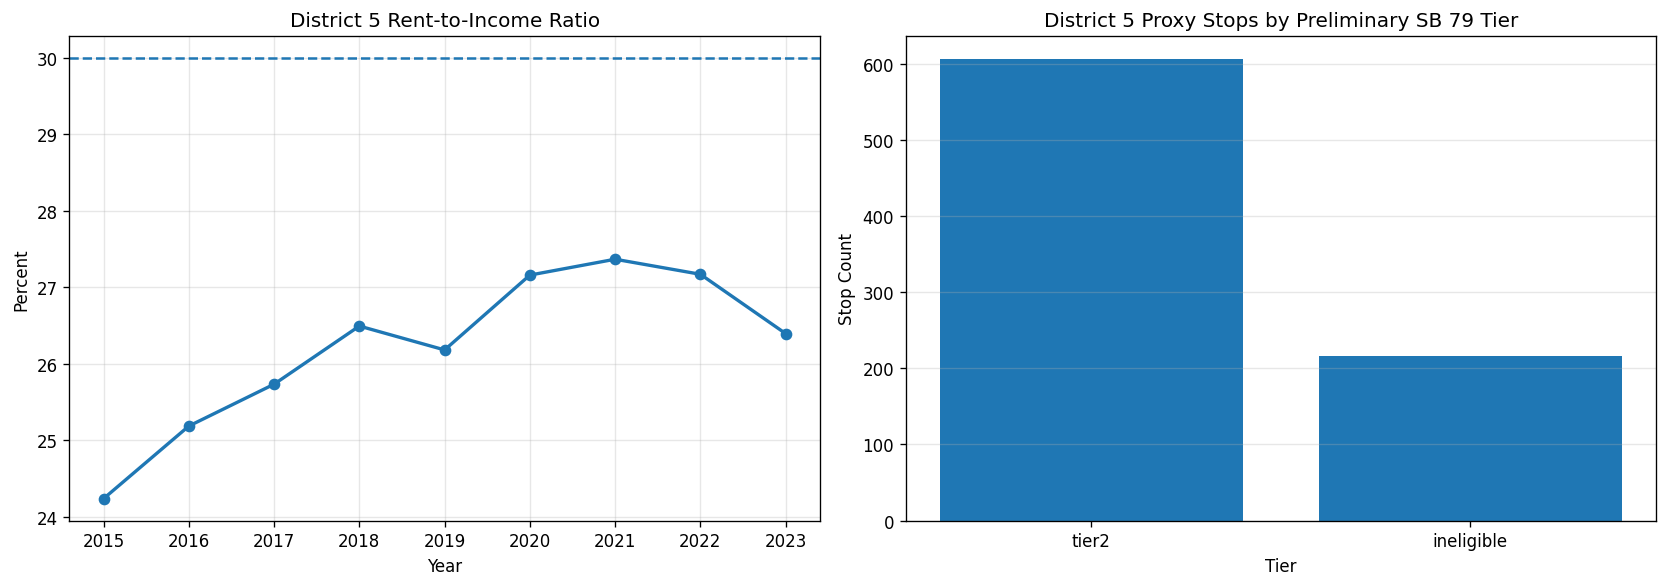

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

axes[0].plot(d5_housing["year"], d5_housing["rent_to_income_ratio"], marker="o", linewidth=2)
axes[0].axhline(30.0, linestyle="--", linewidth=1.5)
axes[0].set_title("District 5 Rent-to-Income Ratio")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Percent")
axes[0].grid(alpha=0.3)

tier_plot = d5_tier_summary[d5_tier_summary["prelim_sb79_tier"].isin(["tier1", "tier2", "ineligible"])].copy()
axes[1].bar(tier_plot["prelim_sb79_tier"], tier_plot["stop_count"])
axes[1].set_title("District 5 Proxy Stops by Preliminary SB 79 Tier")
axes[1].set_xlabel("Tier")
axes[1].set_ylabel("Stop Count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Notes

- Stop tagging is a District 5 proxy based on ZIP centroids and distance thresholds, not parcel geometry.
- Preliminary tier labels are from GTFS service-intensity heuristics and should be validated against final agency maps.
- This notebook is designed to plug into your next phase: parcel and zoning joins.